## 라이브러리 불러오기

In [1]:
# 패키지 설치
!pip install scikit-learn seaborn matplotlib xgboost scipy geopandas

# 기본
import pandas as pd
import numpy as np
import re
import ast
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 기타
import xgboost as xgb
import geopandas as gpd
from scipy.ndimage import gaussian_filter1d

# 시각화 설정
plt.style.use('ggplot')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 파일 불러오기

In [2]:
df = pd.read_csv("final_airbnb.csv")

print(df.shape)
df.head()

(12222, 37)


,id,name,listing_url,price,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,...,calculated_host_listings_count,availability_365,instant_bookable,dist_to_station,stations_within_500m,dist_to_Shinjuku,dist_to_Tokyo,dist_to_Shibuya,land_price,dist_to_land
0,197677,Oshiage Holiday Apartment,https://www.airbnb.com/rooms/197677,"$12,600.00",Entire home/apt,Entire rental unit,2,1.0,2.0,1 bath,...,1,183,f,680.592170,0.0,14529.128425,8263.854679,16020.647615,565000,362.520859
1,1016831,5 mins Shibuya Cat modern sunny Shimokita,https://www.airbnb.com/rooms/1016831,"$24,143.00",Private room,Private room in home,2,1.0,4.0,1 shared bath,...,1,80,f,401.085320,1.0,5376.894735,11041.134716,3329.576245,996000,296.612219
2,1196177,Homestay at Host's House - Senju-Ohashi Station,https://www.airbnb.com/rooms/1196177,"$8,795.00",Private room,Private room in home,3,1.0,8.0,1.5 baths,...,1,253,f,234.042950,1.0,13234.291408,9260.577789,15877.776416,860000,309.270900
3,1268465,No share Private APT 8 min from Ebisu station,https://www.airbnb.com/rooms/1268465,"$11,699.00",Private room,Private room in rental unit,2,0.0,1.0,Private half-bath,...,1,21,t,980.558026,0.0,6939.350647,8514.985876,2820.236212,1470000,194.130389
4,1298200,"2 Bed Room + 2 Toilets, drop off luggage from 9am",https://www.airbnb.com/rooms/1298200,"$18,575.00",Entire home/apt,Entire home,3,2.0,4.0,2 baths,...,6,129,f,462.263242,1.0,18243.999145,12446.337616,20097.190843,780000,485.053012


## 모델 학습을 위한 데이터 전처리

In [3]:
# ============================================================
# host 데이터 이진변수로 변환
# ============================================================

binary_cols = [
    "host_is_superhost",
    "host_identity_verified",
    "instant_bookable"
]

for col in binary_cols:
    if col in df.columns:
        print(df[col].unique()[:10])  # 먼저 원본 확인

        df[col] = df[col].map({
            "t": 1,
            "f": 0,
            True: 1,
            False: 0
        })

['t' 'f']
['t' 'f']
['f' 't']


In [4]:
# ============================================================
# target 변수 price 정리
# ============================================================

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# 가격 분포 확인
print(df["price"].describe())

count    1.222200e+04
mean     1.650637e+04
std      2.559253e+04
min      1.700000e+03
25%      1.018300e+04
50%      1.352100e+04
75%      1.845800e+04
max      1.742858e+06
Name: price, dtype: float64


In [5]:
# ============================================================
# 가격 이상치 제거
# ============================================================

lower = df["price"].quantile(0.01)
upper = df["price"].quantile(0.99)

df = df[(df["price"] >= lower) & (df["price"] <= upper)].copy()

print("이상치 제거 후 데이터 크기:", df.shape)
print(df["price"].describe())

이상치 제거 후 데이터 크기: (11977, 37)
count    11977.000000
mean     15341.386324
std       7248.642920
min       4972.000000
25%      10269.000000
50%      13521.000000
75%      18286.000000
max      50715.000000
Name: price, dtype: float64


In [6]:
# ============================================================
# 로그 가격 생성
# ============================================================

df["log_price"] = np.log1p(df["price"])

print(df[["price", "log_price"]].head())

     price  log_price
0  12600.0   9.441531
1  24143.0  10.091791
2   8795.0   9.082052
3  11699.0   9.367344
4  18575.0   9.829626


In [7]:
# ============================================================
# 퍼센트 변수 숫자화
# ============================================================

percent_cols = ["host_response_rate", "host_acceptance_rate"]

for col in percent_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("%", "", regex=False)
            .replace("nan", np.nan)
            .astype(float)
        )

In [8]:
# ============================================================
# bathrooms_text에서 욕실 수 추출
# ============================================================

def extract_bathrooms(text):
    text = str(text).lower()
    
    if "half-bath" in text or "half bath" in text:
        return 0.5
    
    match = re.search(r"(\d+\.?\d*)", text)
    if match:
        return float(match.group(1))
    else:
        return np.nan

df["bathrooms"] = df["bathrooms_text"].apply(extract_bathrooms)

In [9]:
# ============================================================
# 편의시설 여부 변수 생성
# ============================================================
important_amenities = {
    "has_wifi": "Wifi",
    "has_air_conditioning": "Air conditioning",
    "has_kitchen": "Kitchen",
    "has_washer": "Washer",
    "has_tv": "TV",
    "has_elevator": "Elevator",
    "has_self_checkin": "Self check-in"
}

def has_amenity(x, keyword):
    try:
        amenities_list = ast.literal_eval(x)
        amenities_text = " ".join(amenities_list).lower()
        return int(keyword.lower() in amenities_text)
    except:
        return 0

for new_col, keyword in important_amenities.items():
    df[new_col] = df["amenities"].apply(lambda x: has_amenity(x, keyword))

In [11]:
# ============================================================
# 거리 변수 km 단위로 변환
# ============================================================

distance_cols = [
    "dist_to_station",
    "dist_to_Shinjuku",
    "dist_to_Tokyo",
    "dist_to_Shibuya",
    "dist_to_land"
]

for col in distance_cols:
    if col in df.columns:
        df[col + "_km"] = df[col] / 1000

In [12]:
# ============================================================
# land_price 로그 변환
# ============================================================

df["log_land_price"] = np.log1p(df["land_price"])

In [13]:
# ============================================================
# 변수군 정의
# ============================================================

# 1) 위치 관련 변수
location_features = [
    "neighbourhood_cleansed",
    "dist_to_station_km",
    "stations_within_500m",
    "dist_to_Shinjuku_km",
    "dist_to_Tokyo_km",
    "dist_to_Shibuya_km",
    "log_land_price",
    "dist_to_land_km"
]

# 2) 내부 스펙 관련 변수
internal_features = [
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "has_wifi",
    "has_air_conditioning",
    "has_kitchen",
    "has_washer",
    "has_tv",
    "has_elevator",
    "has_self_checkin"
]

# 3) 리뷰 관련 변수
review_features = [
    "review_scores_rating",
    "review_scores_value",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_accuracy",
    "number_of_reviews"
]

# 4) 호스트 관련 변수
host_features = [
    "host_is_superhost",
    "host_response_rate",
    "host_acceptance_rate",
    "host_identity_verified",
    "calculated_host_listings_count"
]

# 5) 예약/운영 관련 변수
booking_features = [
    "minimum_nights",
    "availability_365",
    "instant_bookable"
]

# 전체 feature
feature_cols = (
    location_features
    + internal_features
    + review_features
    + host_features
    + booking_features
)

# 실제 존재하는 컬럼만 사용
feature_cols = [col for col in feature_cols if col in df.columns]

print("사용할 변수 개수:", len(feature_cols))
print(feature_cols)

사용할 변수 개수: 37
['neighbourhood_cleansed', 'dist_to_station_km', 'stations_within_500m', 'dist_to_Shinjuku_km', 'dist_to_Tokyo_km', 'dist_to_Shibuya_km', 'log_land_price', 'dist_to_land_km', 'room_type', 'property_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'has_wifi', 'has_air_conditioning', 'has_kitchen', 'has_washer', 'has_tv', 'has_elevator', 'has_self_checkin', 'review_scores_rating', 'review_scores_value', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_checkin', 'review_scores_communication', 'review_scores_accuracy', 'number_of_reviews', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'host_identity_verified', 'calculated_host_listings_count', 'minimum_nights', 'availability_365', 'instant_bookable']


In [14]:
# ============================================================
# X, y 정의
# ============================================================

X = df[feature_cols].copy()
y = df["log_price"].copy()

print(X.shape)
print(y.shape)

(11977, 37)
(11977,)


In [15]:
# ============================================================
#수치형 / 범주형 변수 분리
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("수치형 변수:")
print(numeric_features)

print("\n범주형 변수:")
print(categorical_features)

수치형 변수:
['dist_to_station_km', 'stations_within_500m', 'dist_to_Shinjuku_km', 'dist_to_Tokyo_km', 'dist_to_Shibuya_km', 'log_land_price', 'dist_to_land_km', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'has_wifi', 'has_air_conditioning', 'has_kitchen', 'has_washer', 'has_tv', 'has_elevator', 'has_self_checkin', 'review_scores_rating', 'review_scores_value', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_checkin', 'review_scores_communication', 'review_scores_accuracy', 'number_of_reviews', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'host_identity_verified', 'calculated_host_listings_count', 'minimum_nights', 'availability_365', 'instant_bookable']

범주형 변수:
['neighbourhood_cleansed', 'room_type', 'property_type']


In [16]:
# ============================================================
# 전처리 파이프라인
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [17]:
# ============================================================
# train/test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9581, 37)
X_test: (2396, 37)
y_train: (9581,)
y_test: (2396,)


In [18]:
# ============================================================
# 전처리 적용 테스트
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("전처리 후 X_train shape:", X_train_processed.shape)
print("전처리 후 X_test shape:", X_test_processed.shape)

전처리 후 X_train shape: (9581, 126)
전처리 후 X_test shape: (2396, 126)


## 모델 학습

In [19]:
# ============================================================
# 모델 정의 및 학습
# ============================================================
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb

models = {
    "Ridge":            Ridge(alpha=1.0),
    "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost":          xgb.XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0)
}

pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"{name} 학습 완료")

Ridge 학습 완료
RandomForest 학습 완료
GradientBoosting 학습 완료
XGBoost 학습 완료


In [21]:
# ============================================================
# 모델 성능 비교
# ============================================================

results = []

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    
    mae_price = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
    
    results.append({
        "Model": name,
        "MAE (log)": round(mae, 4),
        "RMSE (log)": round(rmse, 4),
        "R²": round(r2, 4),
        "MAE (¥)": round(mae_price, 0)
    })

results_df = pd.DataFrame(results).sort_values("R²", ascending=False)
print(results_df.to_string(index=False))

           Model  MAE (log)  RMSE (log)     R²  MAE (¥)
         XGBoost     0.1683      0.2345 0.6985   2633.0
    RandomForest     0.1664      0.2354 0.6960   2603.0
GradientBoosting     0.2030      0.2676 0.6071   3169.0
           Ridge     0.2313      0.2979 0.5131   3623.0


In [22]:
# ============================================================
# Best Model = XGBoost 
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_pipe = pipelines[best_model_name]
print(f"Best Model: {best_model_name}")

# 전처리 후 feature 이름 복원
ohe_cols = (
    best_pipe.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

all_feature_names = numeric_features + ohe_cols

Best Model: XGBoost


In [23]:
# feature importance 추출
importances = best_pipe.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(fi_df.head(20))

                                      feature  importance
0          property_type_Private room in home    0.058212
1                      room_type_Private room    0.057841
2                                accommodates    0.049794
3              neighbourhood_cleansed_Chuo Ku    0.048277
4                           host_is_superhost    0.047620
5          neighbourhood_cleansed_Akiruno Shi    0.038882
6            property_type_Room in aparthotel    0.038390
7                                has_elevator    0.036074
8   property_type_Private room in rental unit    0.033886
9                            dist_to_Tokyo_km    0.031991
10                     host_identity_verified    0.029214
11                property_type_Room in hotel    0.025159
12                         dist_to_Shibuya_km    0.020696
13                                     has_tv    0.018786
14    property_type_Entire serviced apartment    0.018626
15                                   bedrooms    0.018465
16            

## 1. 가격 영향 요인 

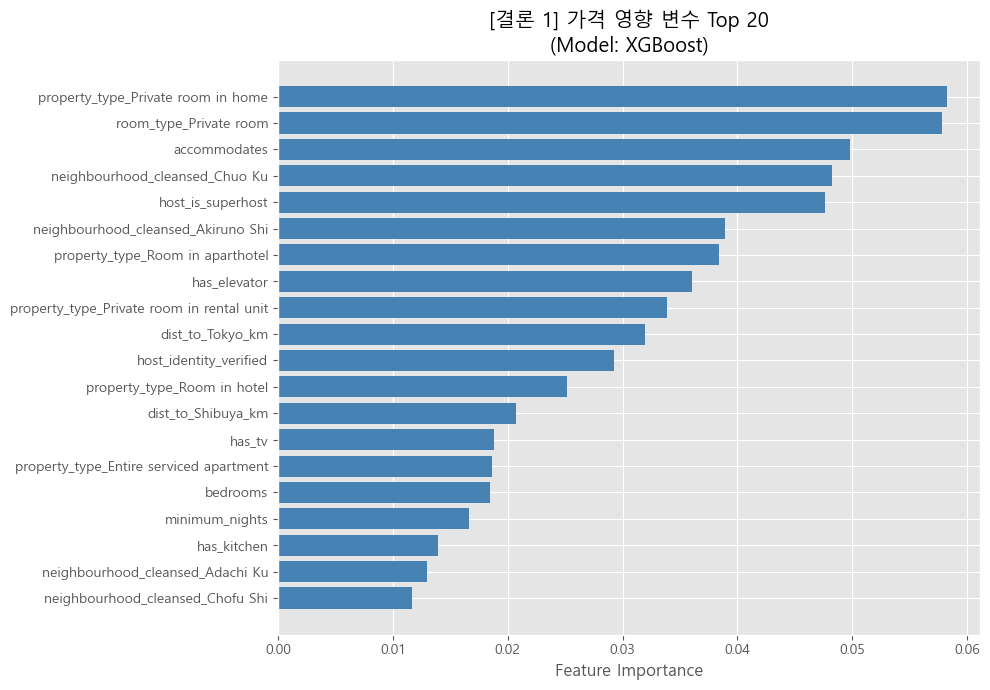

In [24]:
# ============================================================
# [결론 1] 가격 영향 변수 비중 — Top 20
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"   # Windows
# matplotlib.rcParams["font.family"] = "AppleGothic"   # Mac

top20 = fi_df.head(20)

plt.figure(figsize=(10, 7))
plt.barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance")
plt.title(f"[결론 1] 가격 영향 변수 Top 20\n(Model: {best_model_name})")
plt.tight_layout()
plt.savefig("result_01_feature_importance.png", dpi=150)
plt.show()

## 2. 변수군별 중요도 비교

In [25]:
# 각 변수군별 importance 합산
def group_importance(fi_df, feature_list, label):
    mask = fi_df["feature"].apply(
        lambda x: any(x == f or x.startswith(f + "_") for f in feature_list)
    )
    total = fi_df.loc[mask, "importance"].sum()
    return {"group": label, "importance": round(total, 4)}

group_results = [
    group_importance(fi_df, location_features,  "Location"),
    group_importance(fi_df, internal_features,  "Internal Spec"),
    group_importance(fi_df, review_features,    "Review"),
    group_importance(fi_df, host_features,      "Host"),
    group_importance(fi_df, booking_features,   "Booking"),
]

group_df = pd.DataFrame(group_results).sort_values("importance", ascending=False)
print(group_df)

           group  importance
1  Internal Spec      0.5026
0       Location      0.3382
3           Host      0.1007
2         Review      0.0327
4        Booking      0.0258


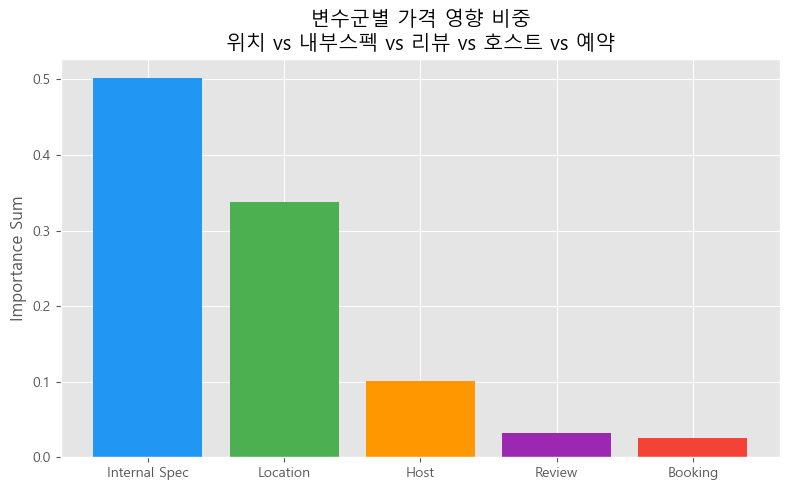

           group  importance      비율(%)
1  Internal Spec      0.5026  50.299999
0       Location      0.3382  33.799999
3           Host      0.1007  10.100000
2         Review      0.0327   3.300000
4        Booking      0.0258   2.600000


In [26]:
# 시각화
plt.figure(figsize=(8, 5))
plt.bar(group_df["group"], group_df["importance"],
        color=["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"])
plt.ylabel("Importance Sum")
plt.title("변수군별 가격 영향 비중\n위치 vs 내부스펙 vs 리뷰 vs 호스트 vs 예약")
plt.tight_layout()
plt.savefig("result_02_group_importance.png", dpi=150)
plt.show()

# 비율로도 출력
total_imp = group_df["importance"].sum()
group_df["비율(%)"] = (group_df["importance"] / total_imp * 100).round(1)
print(group_df)

## 3. 역 접근성에 따른 가격 변화 및 둔화구간 탐색

In [60]:
# 1. 대표 숙소 생성 
base_row = X_train[numeric_features].median().to_dict()
for col in categorical_features:
    if col in X_train.columns:
        base_row[col] = X_train[col].mode()[0]

# 2.역까지 거리 변화 범위 설정
dist_range = np.arange(0.1, 1.9, 0.1)  
pred_prices = []

# 3.거리별 예측 가격 계산
for dist in dist_range:
    # 현재 조사하려는 거리(dist)의 앞뒤 0.2km 이내에 있는 실제 데이터를 필터링
    similar_data = X_train[
        (X_train['dist_to_station_km'] >= dist - 0.2) & 
        (X_train['dist_to_station_km'] <= dist + 0.2)
    ]
    # 데이터 없으면 전체 데이터 사용
    if len(similar_data) == 0:
        similar_data = X_train

    row = base_row.copy()

    row['dist_to_station_km'] = dist
    row['log_land_price'] = similar_data['log_land_price'].median()
    
    if 'stations_within_500m' in row:
        row['stations_within_500m'] = similar_data['stations_within_500m'].median()
    if 'dist_to_Shinjuku_km' in row:
        row['dist_to_Shinjuku_km'] = similar_data['dist_to_Shinjuku_km'].median()
    if 'dist_to_Tokyo_km' in row:
        row['dist_to_Tokyo_km'] = similar_data['dist_to_Tokyo_km'].median()
    if 'dist_to_Shibuya_km' in row:
        row['dist_to_Shibuya_km'] = similar_data['dist_to_Shibuya_km'].median()

    # 예측용 Dataframe 생성
    row_df = pd.DataFrame([row])
    row_df = row_df[feature_cols]   

    # 가격 예측
    log_pred = best_pipe.predict(row_df)[0]
    pred_prices.append(np.expm1(log_pred))

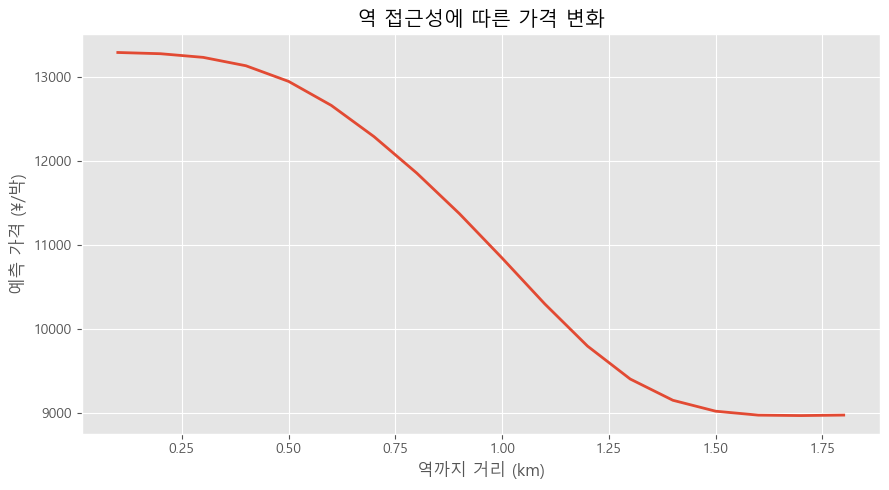

In [61]:
from scipy.ndimage import gaussian_filter1d

# smoothing
smooth_prices = gaussian_filter1d(pred_prices, sigma=2)

plt.figure(figsize=(9, 5))

plt.plot(
    dist_range,
    smooth_prices,
    linewidth=2,
)

plt.xlabel("역까지 거리 (km)")
plt.ylabel("예측 가격 (¥/박)")

plt.title("역 접근성에 따른 가격 변화")

plt.tight_layout()
plt.savefig("result_03_station_access.png", dpi=150)
plt.show()

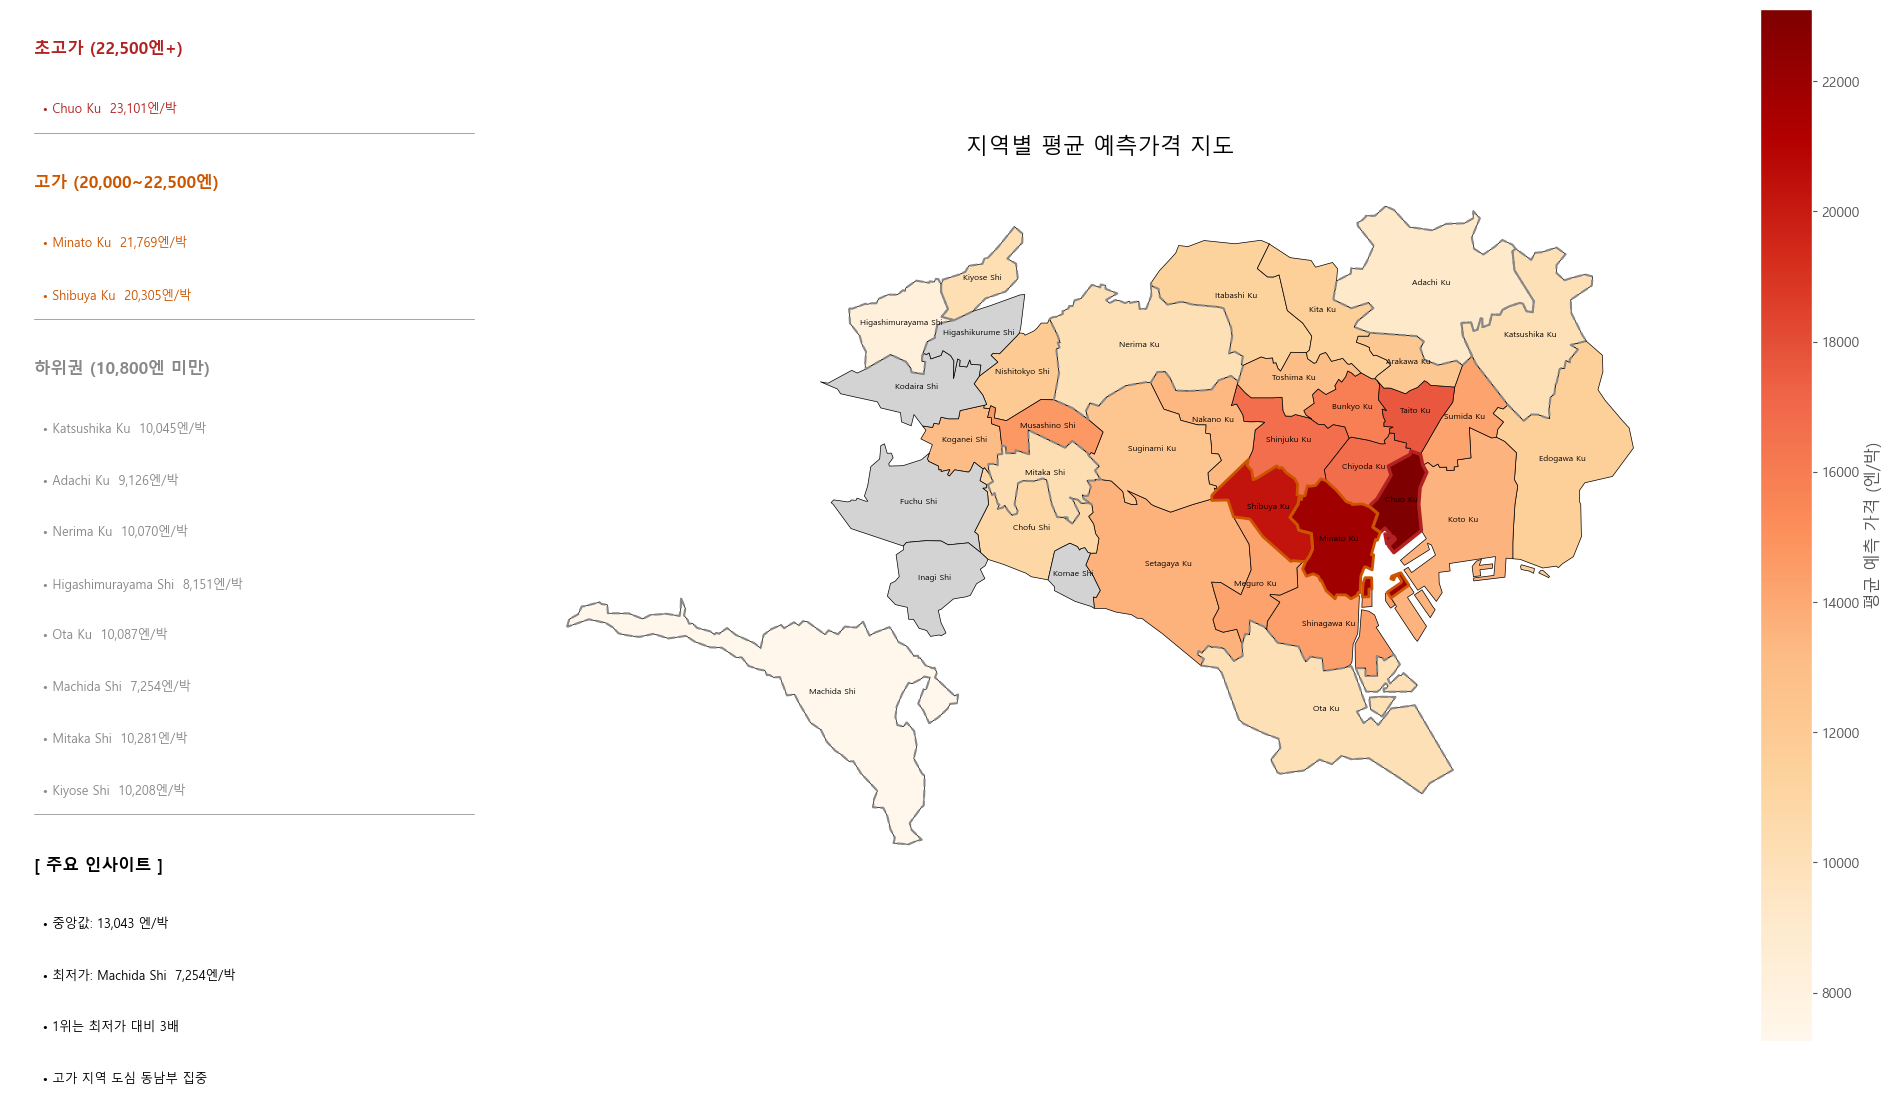

In [57]:
import geopandas as gpd

tokyo_map = gpd.read_file("neighbourhoods.geojson")
tokyo_map = tokyo_map.cx[139.5:139.95, 35.5:35.85]

map_df = X_test.copy()
map_df["pred_price"] = np.expm1(best_pipe.predict(X_test))

neigh_price = (
    map_df
    .groupby("neighbourhood_cleansed")["pred_price"]
    .mean()
    .reset_index()
)

map_merged = tokyo_map.merge(
    neigh_price,
    left_on="neighbourhood",
    right_on="neighbourhood_cleansed",
    how="left"
)

# 4그룹 분류
def classify(price):
    if pd.isna(price):
        return None
    elif price > 22500:
        return "초고가"
    elif price >= 20000:
        return "고가"
    elif price >= 10800:
        return "중위권"
    else:
        return "하위권"

map_merged['group'] = map_merged['pred_price'].apply(classify)

top3     = map_merged[map_merged['group'] == '초고가'].reset_index(drop=True)
high     = map_merged[map_merged['group'] == '고가'].reset_index(drop=True)
low      = map_merged[map_merged['group'] == '하위권'].reset_index(drop=True)
bottom1  = map_merged.nsmallest(1, 'pred_price').reset_index(drop=True)
median_price = int(map_merged['pred_price'].median())

q75 = map_merged['pred_price'].quantile(0.75)
q25 = map_merged['pred_price'].quantile(0.25)
outlier_threshold = int(q75 + 1.5 * (q75 - q25))

fig, (ax_text, ax_map) = plt.subplots(1, 2, figsize=(20, 11),
                                       gridspec_kw={'width_ratios': [1, 3]})
ax_text.axis("off")

y = 0.97

# 초고가
ax_text.text(0.05, y, "초고가 (22,500엔+)",
             fontsize=12, fontweight='bold', color='#b22222',
             transform=ax_text.transAxes, va='top')
y -= 0.06
for _, row in top3.iterrows():
    ax_text.text(0.05, y,
        f"  • {row['neighbourhood']}  {int(row['pred_price']):,}엔/박 ",
        fontsize=9, color='#b22222',
        transform=ax_text.transAxes, va='top')
    y -= 0.05

ax_text.axhline(y=y+0.02, xmin=0.05, xmax=0.95, color='gray', linewidth=0.5)
y -= 0.02

# 고가
ax_text.text(0.05, y, "고가 (20,000~22,500엔)",
             fontsize=12, fontweight='bold', color='#cc5500',
             transform=ax_text.transAxes, va='top')
y -= 0.06
for _, row in high.iterrows():
    ax_text.text(0.05, y,
        f"  • {row['neighbourhood']}  {int(row['pred_price']):,}엔/박",
        fontsize=9, color='#cc5500',
        transform=ax_text.transAxes, va='top')
    y -= 0.05

ax_text.axhline(y=y+0.02, xmin=0.05, xmax=0.95, color='gray', linewidth=0.5)
y -= 0.02

# 하위권
ax_text.text(0.05, y, "하위권 (10,800엔 미만)",
             fontsize=12, fontweight='bold', color='#888888',
             transform=ax_text.transAxes, va='top')
y -= 0.06
for _, row in low.iterrows():
    ax_text.text(0.05, y,
        f"  • {row['neighbourhood']}  {int(row['pred_price']):,}엔/박",
        fontsize=9, color='#888888',
        transform=ax_text.transAxes, va='top')
    y -= 0.05

ax_text.axhline(y=y+0.02, xmin=0.05, xmax=0.95, color='gray', linewidth=0.5)
y -= 0.02

# 인사이트
ax_text.text(0.05, y, "[ 주요 인사이트 ]",
             fontsize=12, fontweight='bold',
             transform=ax_text.transAxes, va='top')
y -= 0.06
ax_text.text(0.05, y, f"  • 중앙값: {median_price:,} 엔/박",
             fontsize=9, transform=ax_text.transAxes, va='top')
y -= 0.05
ax_text.text(0.05, y, f"  • 최저가: {bottom1.iloc[0]['neighbourhood']}  {int(bottom1.iloc[0]['pred_price']):,}엔/박",
             fontsize=9, transform=ax_text.transAxes, va='top')
y -= 0.05
ax_text.text(0.05, y, f"  • 1위는 최저가 대비 {int(top3.iloc[0]['pred_price'] / bottom1.iloc[0]['pred_price']):.0f}배",
             fontsize=9, transform=ax_text.transAxes, va='top')
y -= 0.05
ax_text.text(0.05, y, "  • 고가 지역 도심 동남부 집중",
             fontsize=9, transform=ax_text.transAxes, va='top')

# 지도
map_merged.plot(
    column="pred_price", cmap="OrRd", legend=True,
    linewidth=0.5, edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "데이터 없음"},
    legend_kwds={"label": "평균 예측 가격 (엔/박)", "orientation": "vertical"},
    ax=ax_map
)
for idx, row in map_merged.iterrows():
    if row.geometry is not None:
        ax_map.annotate(row['neighbourhood'],
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=6, ha='center', color='black')

# 그룹별 테두리
top3.plot(ax=ax_map, color='none', edgecolor='#b22222', linewidth=2.5)
high.plot(ax=ax_map, color='none', edgecolor='#cc5500', linewidth=2)
low.plot(ax=ax_map, color='none', edgecolor='#888888', linewidth=1.5, linestyle='--')

ax_map.set_title("지역별 평균 예측가격 지도", fontsize=16, pad=15)
ax_map.axis("off")
plt.tight_layout()
plt.savefig("map_final.png", dpi=150, bbox_inches='tight')
plt.show()